# Condition-layer accuracy figures — internal representation probes

Rebuilds the FULL vs NEUTRAL vs shuffled-control accuracy plots from the
per-condition checkpoint JSONs written by `condition_layer_sweep.py`.

Each checkpoint (`checkpoints/<CONDITION>.json`) holds `layers`, `cv_mean`,
and the matching `control_cv_mean` (shuffled-label control).

The **NEUTRAL** curve shown here is the `NEUTRAL_USER_ONLY` checkpoint (brown X),
matching the original `acc_full_neutral` figure. Point `SWEEP_DIR` at whichever
run you want (v4 by default).

In [24]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "internal_representation_personas").exists():
            return p
    return Path.cwd()


REPO_ROOT = _repo_root()
SWEEP_DIR = (
    REPO_ROOT
    / "internal_representation_personas"
    / "results_modal_gemma4_31b_sweep_v4"
    / "sweep"
)
CKPT_DIR = SWEEP_DIR / "checkpoints"

# Which checkpoint provides the 'NEUTRAL' curve in the figure.
NEUTRAL_CKPT = "NEUTRAL_USER_ONLY"


def _load(name):
    return json.loads((CKPT_DIR / f"{name}.json").read_text())


full = _load("FULL")
neutral = _load(NEUTRAL_CKPT)
layers = np.asarray(full["layers"])

print(f"Sweep dir : {SWEEP_DIR}")
print(f"Checkpoints: {sorted(p.stem for p in CKPT_DIR.glob('*.json'))}")
print(f"Layers     : {layers.min()}-{layers.max()} ({len(layers)} points)")
print(f"FULL       : cv[0]={full['cv_mean'][0]:.3f} -> cv[-1]={full['cv_mean'][-1]:.3f}")
print(f"NEUTRAL    : flat ~{np.mean(neutral['cv_mean']):.3f}")
print(f"Control    : flat ~{np.mean(neutral['control_cv_mean']):.3f}")

Sweep dir : /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/internal_representation_personas/results_modal_gemma4_31b_sweep_v4/sweep
Checkpoints: ['FULL', 'NEUTRAL_GENERATED', 'NEUTRAL_USER_ONLY', 'ONLY_ARTIST', 'ONLY_HOBBY', 'ONLY_MOVIE', 'ONLY_NAME']
Layers     : 0-60 (61 points)
FULL       : cv[0]=0.545 -> cv[-1]=1.000
NEUTRAL    : flat ~0.541
Control    : flat ~0.536


## Clean FULL vs NEUTRAL figure

- Full Layer x-axis kept, but a **marker only every 10 layers**.
- **y-axis tightened** to `[0.5, 1.02]` so the empty band is gone.
- NEUTRAL and shuffled-control markers **alternate** along the axis so the
  control is no longer buried under NEUTRAL.
- Shuffled-control line made **darker / thicker** and the **chance** (0.5) line
  made clearly visible.

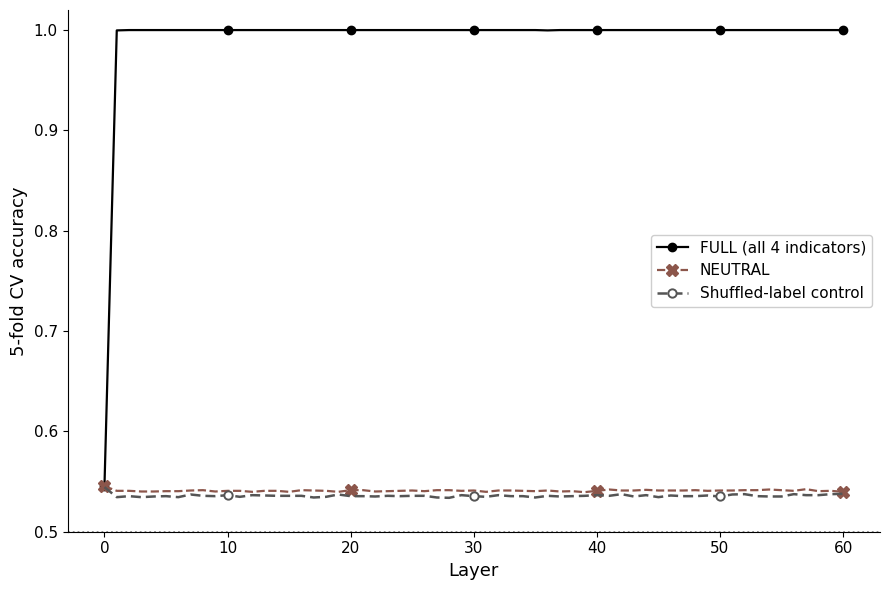

saved -> /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/internal_representation_personas/results_modal_gemma4_31b_sweep_v4/sweep/acc_full_neutral_v2_notitle.png


In [25]:
# Marker every 10 layers (0, 10, 20, ... plus the final layer so the end shows).
step = 10
mark_idx = list(range(0, len(layers), step))
if mark_idx[-1] != len(layers) - 1:
    mark_idx.append(len(layers) - 1)
mark_idx = np.asarray(mark_idx)

# Alternate NEUTRAL / control markers: NEUTRAL on even positions, control on odd.
neu_mark = list(mark_idx[::2])
ctrl_mark = list(mark_idx[1::2])

fig, ax = plt.subplots(figsize=(9, 6))

# FULL — black line, dot every 10 layers.
ax.plot(layers, full["cv_mean"], color="#000000", ls="-", lw=1.6,
        marker="o", markersize=6, markevery=list(mark_idx),
        label="FULL (all 4 indicators)")

# NEUTRAL — brown, X markers on even marker positions.
ax.plot(layers, neutral["cv_mean"], color="#8c564b", ls="--", lw=1.6,
        marker="X", markersize=8, markevery=neu_mark, label="NEUTRAL")

# Shuffled-label control — darker/thicker dashed, open dots on odd positions so
# they interleave with the NEUTRAL X markers.
ax.plot(layers, neutral["control_cv_mean"], color="#555555", ls=(0, (4, 2)),
        lw=1.8, marker="o", markersize=6, markerfacecolor="white",
        markeredgecolor="#555555", markeredgewidth=1.4,
        markevery=ctrl_mark, label="Shuffled-label control", zorder=2)

# Chance line — clearly visible.
ax.axhline(0.5, color="grey", lw=1.3, ls=":", alpha=0.9, zorder=1)

# Tighten y so the whitespace band is gone.
ax.set_ylim(0.5, 1.02)

ax.set_xlabel("Layer", fontsize=13)
ax.set_ylabel("5-fold CV accuracy", fontsize=13)
ax.tick_params(labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=11, framealpha=0.95)

fig.tight_layout()
out = SWEEP_DIR / "acc_full_neutral_v2_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## Compact figure — layers 0–30 only

Same visibility treatment (dark thick control line, brown NEUTRAL, visible red
chance line), but:
- **only layers 0–30**,
- **marker at every layer** again (no every-10 trick),
- a **physically shorter figure** (reduced height) so the flat curves aren't
  stretched over a tall canvas.

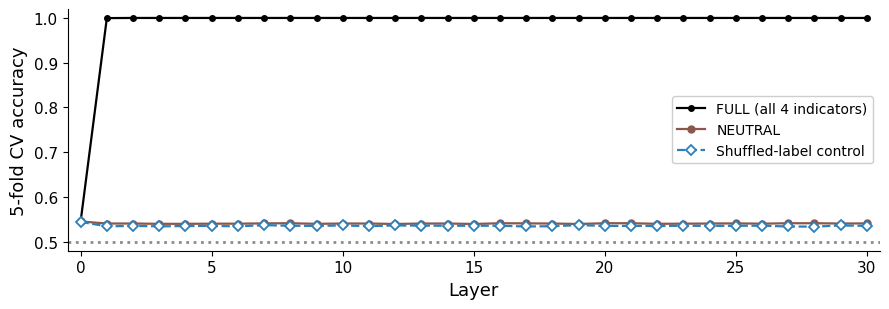

saved -> /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/internal_representation_personas/results_modal_gemma4_31b_sweep_v4/sweep/acc_full_neutral_compact_l0-30_notitle.png


In [26]:
MAX_LAYER = 30
_m = layers <= MAX_LAYER
_L = layers[_m]

fig, ax = plt.subplots(figsize=(9, 3.2))  # shorter figure

# FULL — black, marker at every layer.
ax.plot(_L, np.asarray(full["cv_mean"])[_m], color="#000000", ls="-", lw=1.6,
        marker="o", markersize=4, label="FULL (all 4 indicators)")

# NEUTRAL — brown, filled circles.
ax.plot(_L, np.asarray(neutral["cv_mean"])[_m], color="#8c564b", ls="-", lw=1.6,
        marker="o", markersize=5, label="NEUTRAL")

# Shuffled-label control — distinct blue, hollow diamonds so it clearly reads as
# a separate series from NEUTRAL rather than a near-identical grey/brown band.
ax.plot(_L, np.asarray(neutral["control_cv_mean"])[_m], color="#2c7fb8",
        ls="--", lw=1.6, marker="D", markersize=5,
        markerfacecolor="white", markeredgecolor="#2c7fb8", markeredgewidth=1.3,
        label="Shuffled-label control", zorder=2)

# Chance line — thicker and lifted off the x-axis (floor below 0.5) so it shows.
ax.axhline(0.5, color="grey", lw=2.0, ls=":", alpha=0.9, zorder=1)

ax.set_ylim(0.48, 1.02)
ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)

ax.set_xlabel("Layer", fontsize=13)
ax.set_ylabel("5-fold CV accuracy", fontsize=13)
ax.tick_params(labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=10, framealpha=0.95)

fig.tight_layout()
out = SWEEP_DIR / "acc_full_neutral_compact_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## Alternative — interleaved NEUTRAL / control dots (with lines)

Alternate the two series' **markers** by layer: **NEUTRAL dots on even layers,
shuffled-control dots on odd layers**, so the markers interleave into one band
and read side by side without overlapping. Each series still keeps its
**connecting line through every layer** (via `markevery`, so only the markers
alternate — the lines stay continuous). FULL and the chance line are unchanged.

In [ ]:
MAX_LAYER = 30
_m = layers <= MAX_LAYER
_L = layers[_m]
_neu = np.asarray(neutral["cv_mean"])[_m]
_ctrl = np.asarray(neutral["control_cv_mean"])[_m]

# Full lines through every layer, but markers only on alternating layers:
# NEUTRAL dots on even layers, control dots on odd layers -> interleaved markers
# with continuous connecting lines.
even_idx = list(np.where(_L % 2 == 0)[0])
odd_idx = list(np.where(_L % 2 == 1)[0])

FS = 20  # base font size — big enough to stay readable in the paper
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# FULL — unchanged.
ax.plot(_L, np.asarray(full["cv_mean"])[_m], color="#000000", ls="-", lw=2.2,
        marker="o", markersize=6, label="FULL (all 4 indicators)")

# NEUTRAL — line through all layers, markers on even layers only.
ax.plot(_L, _neu, color="#8c564b", ls="-", lw=2.2,
        marker="o", markersize=9, markevery=even_idx, label="NEUTRAL")

# Shuffled-label control — line through all layers, markers on odd layers only.
ax.plot(_L, _ctrl, color="#2c7fb8", ls="--", lw=2.2,
        marker="D", markersize=9, markevery=odd_idx,
        markerfacecolor="white", markeredgecolor="#2c7fb8", markeredgewidth=1.8,
        label="Shuffled-label control", zorder=2)

# Chance line — thicker and lifted off the x-axis so it shows.
ax.axhline(0.5, color="grey", lw=2.4, ls=":", alpha=0.9, zorder=1)

ax.set_ylim(0.48, 1.02)
ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)

ax.set_xlabel("Layer", fontsize=FS)
ax.set_ylabel("5-fold CV accuracy", fontsize=FS)
ax.tick_params(labelsize=FS - 2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=FS - 5, framealpha=0.95)

fig.tight_layout()
out = SWEEP_DIR / "acc_full_neutral_interleaved_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## Same interleaved figure — e2b run

Exactly the interleaved figure above, but built from the **gemma-4-e2b** sweep
(`results_modal_gemma4_e2b/sweep/checkpoints`). Same `FULL` and
`NEUTRAL_USER_ONLY` checkpoints, same styling. (The e2b sweep runs to layer 35;
the figure still caps at `MAX_LAYER = 30`.)

In [ ]:
# Load the e2b sweep checkpoints (separate vars so the v4 globals are untouched).
E2B_CKPT_DIR = (
    REPO_ROOT
    / "internal_representation_personas"
    / "results_modal_gemma4_e2b"
    / "sweep"
    / "checkpoints"
)
full_e2b = json.loads((E2B_CKPT_DIR / "FULL.json").read_text())
neutral_e2b = json.loads((E2B_CKPT_DIR / f"{NEUTRAL_CKPT}.json").read_text())
layers_e2b = np.asarray(full_e2b["layers"])

MAX_LAYER = 30
_m = layers_e2b <= MAX_LAYER
_L = layers_e2b[_m]
_neu = np.asarray(neutral_e2b["cv_mean"])[_m]
_ctrl = np.asarray(neutral_e2b["control_cv_mean"])[_m]

# Full lines through every layer, but markers only on alternating layers:
# NEUTRAL dots on even layers, control dots on odd layers -> interleaved markers
# with continuous connecting lines.
even_idx = list(np.where(_L % 2 == 0)[0])
odd_idx = list(np.where(_L % 2 == 1)[0])

FS = 20  # base font size — big enough to stay readable in the paper
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# FULL — unchanged.
ax.plot(_L, np.asarray(full_e2b["cv_mean"])[_m], color="#000000", ls="-", lw=2.2,
        marker="o", markersize=6, label="FULL (all 4 indicators)")

# NEUTRAL — line through all layers, markers on even layers only.
ax.plot(_L, _neu, color="#8c564b", ls="-", lw=2.2,
        marker="o", markersize=9, markevery=even_idx, label="NEUTRAL")

# Shuffled-label control — line through all layers, markers on odd layers only.
ax.plot(_L, _ctrl, color="#2c7fb8", ls="--", lw=2.2,
        marker="D", markersize=9, markevery=odd_idx,
        markerfacecolor="white", markeredgecolor="#2c7fb8", markeredgewidth=1.8,
        label="Shuffled-label control", zorder=2)

# Chance line — thicker and lifted off the x-axis so it shows.
ax.axhline(0.5, color="grey", lw=2.4, ls=":", alpha=0.9, zorder=1)

ax.set_ylim(0.48, 1.02)
ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)

ax.set_xlabel("Layer", fontsize=FS)
ax.set_ylabel("5-fold CV accuracy", fontsize=FS)
ax.tick_params(labelsize=FS - 2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=FS - 5, framealpha=0.95)

fig.tight_layout()
out = E2B_CKPT_DIR.parent / "acc_full_neutral_interleaved_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## e2b — add NEUTRAL *with assistant turns*

Same e2b interleaved figure, plus the plain `NEUTRAL` checkpoint (neutral user
words but **assistant turns kept**). Unlike the user-only NEUTRAL (~0.54, flat),
this one climbs to ~0.97 — the assistant replies still leak gender, so the probe
recovers it almost as well as FULL. Shown as a separate green line.

In [ ]:
# e2b checkpoints (E2B_CKPT_DIR / full_e2b / neutral_e2b defined in the cell above).
neutral_asst_e2b = json.loads((E2B_CKPT_DIR / "NEUTRAL.json").read_text())

MAX_LAYER = 30
_m = layers_e2b <= MAX_LAYER
_L = layers_e2b[_m]
_neu = np.asarray(neutral_e2b["cv_mean"])[_m]        # NEUTRAL, user-only
_neu_a = np.asarray(neutral_asst_e2b["cv_mean"])[_m]  # NEUTRAL, with assistant turns
_ctrl = np.asarray(neutral_e2b["control_cv_mean"])[_m]

# NEUTRAL (user-only) dots on even layers, control dots on odd layers.
even_idx = list(np.where(_L % 2 == 0)[0])
odd_idx = list(np.where(_L % 2 == 1)[0])

FS = 20  # base font size — big enough to stay readable in the paper
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# FULL — unchanged.
ax.plot(_L, np.asarray(full_e2b["cv_mean"])[_m], color="#000000", ls="-", lw=2.2,
        marker="o", markersize=6, label="FULL (all 4 indicators)")

# NEUTRAL with assistant turns — new green line (climbs high, ~0.97).
ax.plot(_L, _neu_a, color="#2ca02c", ls="-", lw=2.2,
        marker="^", markersize=8, markevery=odd_idx,
        label="NEUTRAL (+ assistant turns)")

# NEUTRAL user-only — brown, markers on even layers.
ax.plot(_L, _neu, color="#8c564b", ls="-", lw=2.2,
        marker="o", markersize=9, markevery=even_idx, label="NEUTRAL (user only)")

# Shuffled-label control — blue hollow diamonds, markers on odd layers.
ax.plot(_L, _ctrl, color="#2c7fb8", ls="--", lw=2.2,
        marker="D", markersize=9, markevery=odd_idx,
        markerfacecolor="white", markeredgecolor="#2c7fb8", markeredgewidth=1.8,
        label="Shuffled-label control", zorder=2)

# Chance line — thicker and lifted off the x-axis so it shows.
ax.axhline(0.5, color="grey", lw=2.4, ls=":", alpha=0.9, zorder=1)

ax.set_ylim(0.48, 1.02)
ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)

ax.set_xlabel("Layer", fontsize=FS)
ax.set_ylabel("5-fold CV accuracy", fontsize=FS)
ax.tick_params(labelsize=FS - 2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=FS - 7, framealpha=0.95)

fig.tight_layout()
out = E2B_CKPT_DIR.parent / "acc_full_neutral_withasst_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## 31b/v4 — image-#5 style, but with pink NEUTRAL (regenerated + assistant)

Same interleaved layout as the e2b figure (layers 0–30, big text, FULL / +assistant
NEUTRAL / user-only NEUTRAL / control), but the "+assistant" line is the
**regenerated-neutral** condition (`NEUTRAL_GENERATED`, pink stars, ~0.91). That
condition only exists for the **31b/v4** run, so this figure is built from 31b —
e2b has no regenerated-neutral checkpoint.

In [ ]:
# 31b/v4 run: NEUTRAL_GENERATED (pink) exists only for this model — so this
# image-#5-style figure (interleaved, layers 0-30) is built from the 31b sweep.
neutral_gen = json.loads((CKPT_DIR / "NEUTRAL_GENERATED.json").read_text())

MAX_LAYER = 30
_m = layers <= MAX_LAYER
_L = layers[_m]
_full = np.asarray(full["cv_mean"])[_m]
_gen = np.asarray(neutral_gen["cv_mean"])[_m]     # NEUTRAL, regenerated (+assistant)
_uonly = np.asarray(neutral["cv_mean"])[_m]        # NEUTRAL, user only
_ctrl = np.asarray(neutral["control_cv_mean"])[_m]

# Interleave the two flat series' markers: user-only NEUTRAL on even layers,
# control on odd layers (lines stay continuous via markevery).
even_idx = list(np.where(_L % 2 == 0)[0])
odd_idx = list(np.where(_L % 2 == 1)[0])

FS = 20
fig, ax = plt.subplots(figsize=(7.5, 4.2))

# FULL — black.
ax.plot(_L, _full, color="#000000", ls="-", lw=2.2, marker="o", markersize=6,
        label="FULL (all 4 indicators)")

# NEUTRAL (regenerated, with assistant turns) — pink stars, sits just below FULL.
ax.plot(_L, _gen, color="#e377c2", ls="-", lw=2.2, marker="*", markersize=12,
        markevery=odd_idx, label="NEUTRAL (+ assistant turns)")

# NEUTRAL (user only) — brown circles on even layers.
ax.plot(_L, _uonly, color="#8c564b", ls="-", lw=2.2, marker="o", markersize=9,
        markevery=even_idx, label="NEUTRAL (user only)")

# Shuffled-label control — blue hollow diamonds on odd layers.
ax.plot(_L, _ctrl, color="#2c7fb8", ls="--", lw=2.2, marker="D", markersize=9,
        markevery=odd_idx, markerfacecolor="white", markeredgecolor="#2c7fb8",
        markeredgewidth=1.8, label="Shuffled-label control", zorder=2)

# Chance line — thicker, lifted off the x-axis.
ax.axhline(0.5, color="grey", lw=2.4, ls=":", alpha=0.9, zorder=1)

ax.set_ylim(0.48, 1.02)
ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)

ax.set_xlabel("Layer", fontsize=FS)
ax.set_ylabel("5-fold CV accuracy", fontsize=FS)
ax.tick_params(labelsize=FS - 2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=FS - 7, framealpha=0.95)

fig.tight_layout()
out = SWEEP_DIR / "acc_full_neutral_generated_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## Broken y-axis — separate NEUTRAL from control

NEUTRAL (~0.541) sits only ~0.005 above the shuffled control (~0.536), so on a
0.5–1.0 axis they overlap. This version uses a **broken y-axis**: a thin top
panel for FULL (~1.0) and a bottom panel **zoomed to the ~0.53–0.546 band**, so
the small-but-consistent NEUTRAL > control gap is visible. Same colours / chance
line as before.

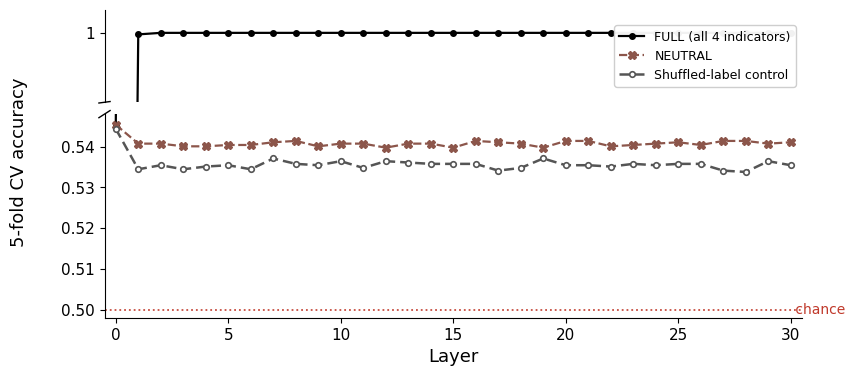

saved -> /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/internal_representation_personas/results_modal_gemma4_31b_sweep_v4/sweep/acc_full_neutral_brokenaxis_l0-30_notitle.png


In [27]:
MAX_LAYER = 30
_m = layers <= MAX_LAYER
_L = layers[_m]
_full = np.asarray(full["cv_mean"])[_m]
_neu = np.asarray(neutral["cv_mean"])[_m]
_ctrl = np.asarray(neutral["control_cv_mean"])[_m]

# Two stacked panels sharing x: top = FULL (~1.0), bottom = zoomed NEUTRAL/control band.
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(9, 4.0),
    gridspec_kw={"height_ratios": [1, 2.2], "hspace": 0.08},
)


def _draw(ax):
    ax.plot(_L, _full, color="#000000", ls="-", lw=1.6, marker="o", markersize=4,
            label="FULL (all 4 indicators)")
    ax.plot(_L, _neu, color="#8c564b", ls="--", lw=1.6, marker="X", markersize=6,
            label="NEUTRAL")
    ax.plot(_L, _ctrl, color="#555555", ls=(0, (4, 2)), lw=1.8, marker="o",
            markersize=4, markerfacecolor="white", markeredgecolor="#555555",
            markeredgewidth=1.2, label="Shuffled-label control", zorder=2)


_draw(ax_top)
_draw(ax_bot)

# Panel y-limits: top around FULL, bottom zoomed to the flat band + chance.
ax_top.set_ylim(0.985, 1.005)
ax_bot.set_ylim(0.498, 0.548)

# Chance line lives in the bottom (zoomed) panel where it's meaningful.
ax_bot.axhline(0.5, color="#c0392b", lw=1.3, ls=":", alpha=0.9, zorder=1)
ax_bot.text(_L[-1], 0.5, " chance", color="#c0392b", va="center", ha="left",
            fontsize=10)

ax_top.set_yticks([1.0])
ax_bot.set_yticks([0.50, 0.51, 0.52, 0.53, 0.54])

# Hide the shared spine between panels + add diagonal break marks.
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)
for ax in (ax_top, ax_bot):
    ax.spines["right"].set_visible(False)
ax_top.spines["top"].set_visible(False)

d = 0.008  # break-mark size in axes coords
kw = dict(transform=ax_top.transAxes, color="k", clip_on=False, lw=1)
ax_top.plot((-d, +d), (-d, +d), **kw)
kw.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d * 2.2, 1 + d * 2.2), **kw)

ax_bot.set_xlim(_L.min() - 0.5, _L.max() + 0.5)
ax_bot.set_xlabel("Layer", fontsize=13)
fig.supylabel("5-fold CV accuracy", fontsize=13, x=0.02)
for ax in (ax_top, ax_bot):
    ax.tick_params(labelsize=11)
ax_top.legend(loc="center right", fontsize=9, framealpha=0.95)

out = SWEEP_DIR / "acc_full_neutral_brokenaxis_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## Single nonlinear y-axis — no broken axis

Instead of two panels, keep **one continuous y-axis** but give it a **nonlinear
scale** (matplotlib `FuncScale`) that stretches the low ~0.50–0.56 band and
compresses the ~0.56–1.0 region. FULL still reaches 1.0, but the small NEUTRAL
vs shuffled-control gap near 0.54 is pulled apart into a readable separation.

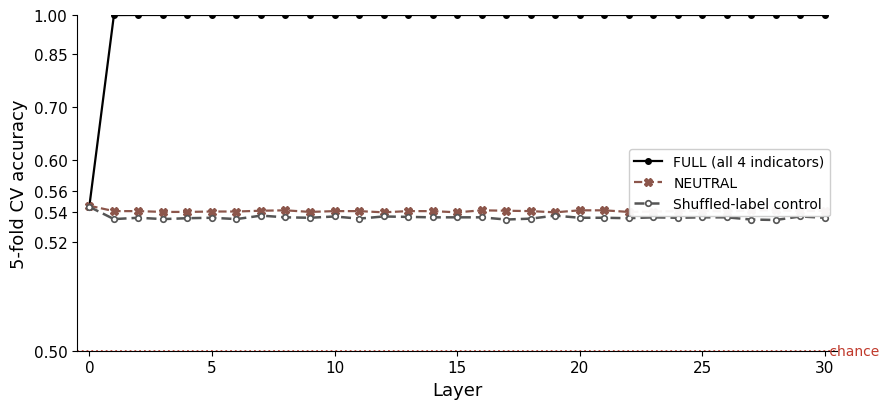

saved -> /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/internal_representation_personas/results_modal_gemma4_31b_sweep_v4/sweep/acc_full_neutral_nonlinear_l0-30_notitle.png


In [28]:
MAX_LAYER = 30
_m = layers <= MAX_LAYER
_L = layers[_m]
_full = np.asarray(full["cv_mean"])[_m]
_neu = np.asarray(neutral["cv_mean"])[_m]
_ctrl = np.asarray(neutral["control_cv_mean"])[_m]

# Nonlinear y-scale: stretch just above chance, compress toward 1.0.
# forward: t = (y - 0.5) ** POWER  (POWER < 1 expands small gaps near 0.5)
BASE = 0.5
POWER = 0.35


def _fwd(y):
    y = np.asarray(y, dtype=float)
    return np.sign(y - BASE) * np.abs(y - BASE) ** POWER


def _inv(t):
    t = np.asarray(t, dtype=float)
    return BASE + np.sign(t) * np.abs(t) ** (1.0 / POWER)


fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(_L, _full, color="#000000", ls="-", lw=1.6, marker="o", markersize=4,
        label="FULL (all 4 indicators)")
ax.plot(_L, _neu, color="#8c564b", ls="--", lw=1.6, marker="X", markersize=6,
        label="NEUTRAL")
ax.plot(_L, _ctrl, color="#555555", ls=(0, (4, 2)), lw=1.8, marker="o",
        markersize=4, markerfacecolor="white", markeredgecolor="#555555",
        markeredgewidth=1.2, label="Shuffled-label control", zorder=2)

ax.axhline(0.5, color="#c0392b", lw=1.3, ls=":", alpha=0.9, zorder=1)
ax.text(_L[-1], 0.5, " chance", color="#c0392b", va="center", ha="left",
        fontsize=10)

ax.set_yscale("function", functions=(_fwd, _inv))
ax.set_ylim(0.5, 1.0)
# Ticks: dense near the interesting band, sparse up top.
ax.set_yticks([0.5, 0.52, 0.54, 0.56, 0.6, 0.7, 0.85, 1.0])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))

ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)
ax.set_xlabel("Layer", fontsize=13)
ax.set_ylabel("5-fold CV accuracy", fontsize=13)
ax.tick_params(labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=10, framealpha=0.95)

fig.tight_layout()
out = SWEEP_DIR / "acc_full_neutral_nonlinear_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")

## Nonlinear y-axis, floor 0.4 — same info, clearer diff & chance line

Same three curves and single continuous (nonlinear) y-axis as above, but:
- **y-axis starts at 0.4**, giving the chance line at 0.5 room above the floor
  so it reads clearly instead of sitting on the bottom edge.
- a slightly **stronger low-band stretch** so the NEUTRAL vs shuffled-control
  gap near 0.54 is a bit more visible. FULL still reaches 1.0 — no information
  removed.

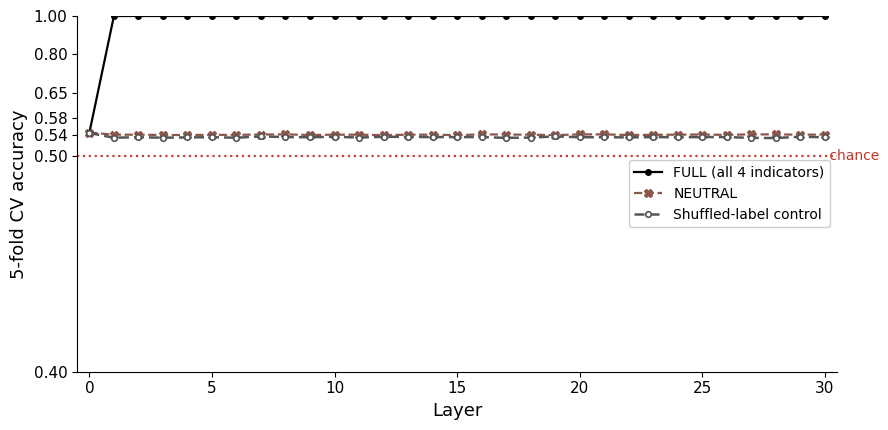

saved -> /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/internal_representation_personas/results_modal_gemma4_31b_sweep_v4/sweep/acc_full_neutral_nonlinear_floor04_l0-30_notitle.png


In [29]:
MAX_LAYER = 30
_m = layers <= MAX_LAYER
_L = layers[_m]
_full = np.asarray(full["cv_mean"])[_m]
_neu = np.asarray(neutral["cv_mean"])[_m]
_ctrl = np.asarray(neutral["control_cv_mean"])[_m]

# Nonlinear y-scale anchored at the 0.4 floor; POWER<1 stretches the low band.
BASE = 0.4
POWER = 0.28


def _fwd(y):
    y = np.asarray(y, dtype=float)
    return np.sign(y - BASE) * np.abs(y - BASE) ** POWER


def _inv(t):
    t = np.asarray(t, dtype=float)
    return BASE + np.sign(t) * np.abs(t) ** (1.0 / POWER)


fig, ax = plt.subplots(figsize=(9, 4.4))

ax.plot(_L, _full, color="#000000", ls="-", lw=1.6, marker="o", markersize=4,
        label="FULL (all 4 indicators)")
ax.plot(_L, _neu, color="#8c564b", ls="--", lw=1.6, marker="X", markersize=6,
        label="NEUTRAL")
ax.plot(_L, _ctrl, color="#555555", ls=(0, (4, 2)), lw=1.8, marker="o",
        markersize=4, markerfacecolor="white", markeredgecolor="#555555",
        markeredgewidth=1.2, label="Shuffled-label control", zorder=2)

# Chance line — now well above the 0.4 floor, so clearly readable.
ax.axhline(0.5, color="#c0392b", lw=1.6, ls=":", alpha=0.95, zorder=1)
ax.text(_L[-1], 0.5, " chance", color="#c0392b", va="center", ha="left",
        fontsize=10)

ax.set_yscale("function", functions=(_fwd, _inv))
ax.set_ylim(0.4, 1.0)
ax.set_yticks([0.4, 0.5, 0.54, 0.58, 0.65, 0.8, 1.0])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))

ax.set_xlim(_L.min() - 0.5, _L.max() + 0.5)
ax.set_xlabel("Layer", fontsize=13)
ax.set_ylabel("5-fold CV accuracy", fontsize=13)
ax.tick_params(labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center right", fontsize=10, framealpha=0.95)

fig.tight_layout()
out = SWEEP_DIR / "acc_full_neutral_nonlinear_floor04_l0-30_notitle.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved -> {out}")